# Trading Strategy Backtester Showcase

## Project Goal

This notebook compares several simple rule-based trading agents using a modular Python backtesting framework.

The purpose is not to build a production trading system. Instead, the project demonstrates how trading rules can be tested under a consistent portfolio-accounting framework and evaluated using risk and return metrics.

## Strategy Set

The project compares five strategies:

1. Random trading baseline
2. Buy-and-hold benchmark
3. Moving-average crossover
4. Momentum
5. Mean reversion

In [1]:
!git clone https://github.com/XinyueJianggg/trading-strategy-backtester.git

fatal: destination path 'trading-strategy-backtester' already exists and is not an empty directory.


In [2]:
%cd trading-strategy-backtester

/content/trading-strategy-backtester


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

In [4]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

#from pathlib import Path
#import sys

#PROJECT_ROOT = Path("..").resolve()
#sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_stock_data
from src.backtester import compare_agents
from src.metrics import summarize_all_strategies
from src.plotting import plot_portfolio_values, plot_drawdowns, plot_return_distribution

from agents import random_agent
from agents import buy_and_hold_agent
from agents import moving_average_agent
from agents import momentum_agent
from agents import mean_reversion_agent

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

np.random.seed(42)

data_path = PROJECT_ROOT / "data" / "stocks"
data_path.mkdir(parents=True, exist_ok=True)

tickers = ["AAPL", "AMD", "AMZN", "BABA", "GOOG", "INTC", "META", "MSFT", "NFLX", "NVDA", "TSLA", "V"]
dates = pd.date_range(start="2025-01-01", periods=100, freq="D")

for ticker in tickers:
    returns = np.random.normal(loc=0.0005, scale=0.02, size=len(dates))
    prices = 100 * (1 + returns).cumprod()

    df = pd.DataFrame({
        "Date": dates,
        "Price": prices.round(2)
    })

    df.to_csv(data_path / f"{ticker}.csv", index=False)

print("Sample stock CSV files created in:", data_path)

Sample stock CSV files created in: /content/trading-strategy-backtester/data/stocks


In [6]:
data_path = PROJECT_ROOT / "data" / "stocks"
price_data = load_stock_data(data_path)

price_data.head()

,Date,AAPL,AMD,AMZN,BABA,GOOG,INTC,META,MSFT,NFLX,NVDA,TSLA,V
0,2025-01-01,101.04,97.22,100.77,98.39,96.86,101.90,101.56,99.00,101.93,100.79,102.85,102.05
1,2025-01-02,100.81,96.45,101.95,97.34,95.75,105.84,99.74,101.13,100.93,100.04,104.80,96.19
2,2025-01-03,102.17,95.84,104.21,98.84,95.81,102.94,101.53,99.76,101.17,100.15,104.98,100.25
3,2025-01-04,105.33,94.35,106.45,100.10,95.94,104.15,104.33,97.00,100.29,102.76,103.67,100.02
4,2025-01-05,104.89,94.09,103.57,100.11,95.13,102.84,105.24,94.03,99.46,103.21,105.17,102.29


In [7]:
agents = {
    "Random": random_agent,
    "Buy and Hold": buy_and_hold_agent,
    "Moving Average": moving_average_agent,
    "Momentum": momentum_agent,
    "Mean Reversion": mean_reversion_agent,
}

results = compare_agents(price_data, agents, initial_cash=100000)
results.head()

,Date,Random,Buy and Hold,Moving Average,Momentum,Mean Reversion
0,2025-01-01,100000.00,100000.000000,100000.0,100000.0,100000.0
1,2025-01-02,100001.69,99716.055747,100000.0,100000.0,100000.0
2,2025-01-03,100003.57,100264.269636,100000.0,100000.0,100000.0
3,2025-01-04,99995.91,100815.624674,100000.0,100000.0,100000.0
4,2025-01-05,99996.94,100443.831075,100000.0,100000.0,100000.0


In [8]:
summary = summarize_all_strategies(results)
summary

,Final Portfolio Value,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Historical VaR 95%,Historical CVaR 95%
Random,100752.930000,0.007529,0.019277,0.006083,3.142032,-0.002386,0.000650,0.000811
Buy and Hold,112999.465883,0.129995,0.364909,0.085194,3.695887,-0.055710,0.007638,0.010501
Moving Average,101138.630000,0.011386,0.029239,0.017941,1.615279,-0.009381,0.001633,0.002373
Momentum,101472.380000,0.014724,0.037906,0.017401,2.146835,-0.007901,0.001687,0.002350
Mean Reversion,100617.180000,0.006172,0.015785,0.008981,1.748364,-0.004791,0.000807,0.001101


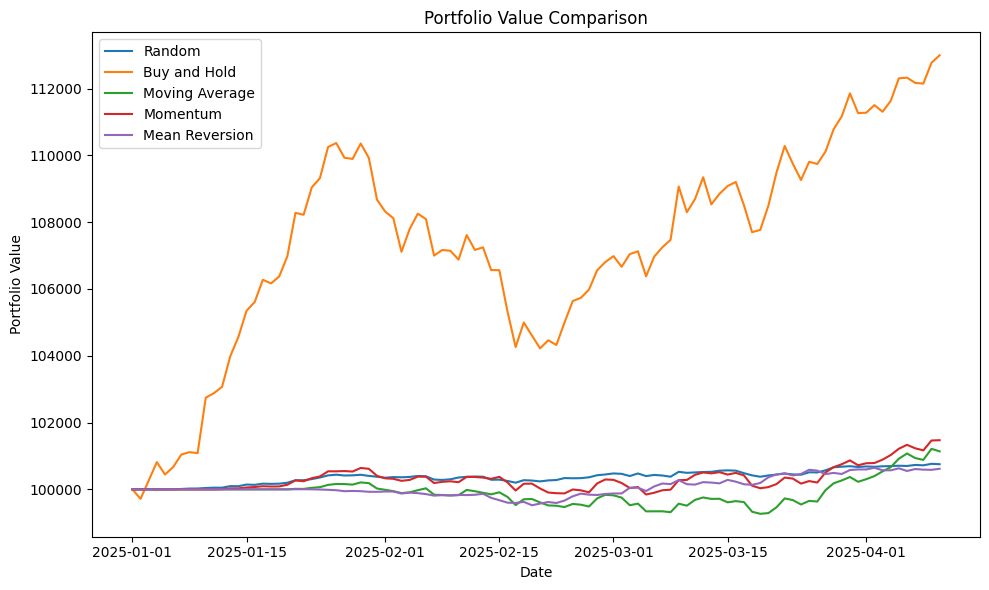

In [9]:
output_dir = PROJECT_ROOT / "outputs"
figure_dir = output_dir / "figures"

output_dir.mkdir(exist_ok=True)
figure_dir.mkdir(exist_ok=True)

results.to_csv(output_dir / "portfolio_values.csv", index=False)
summary.to_csv(output_dir / "strategy_summary.csv")

plot_portfolio_values(results, figure_dir / "portfolio_value_comparison.png")

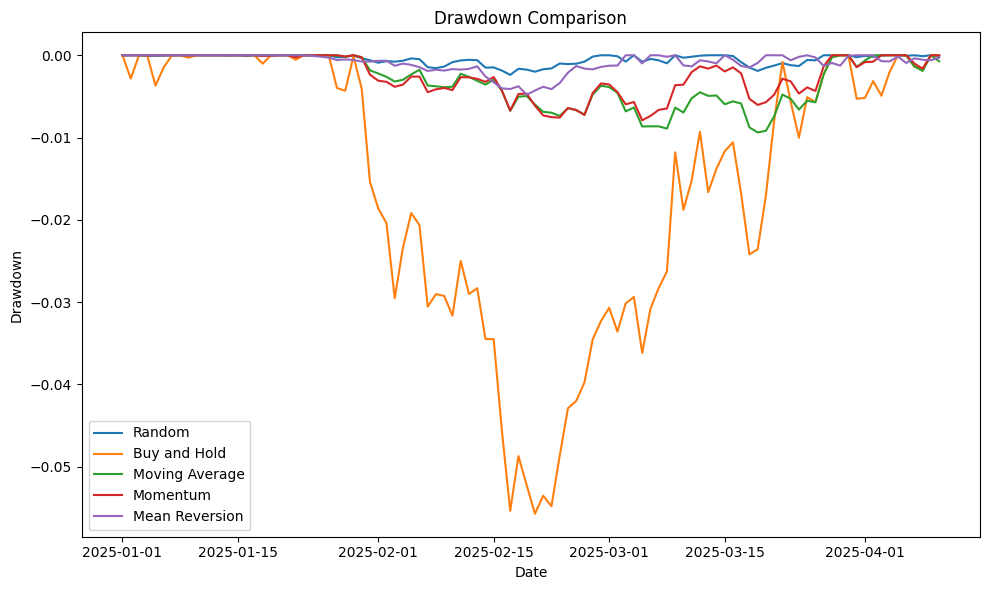

In [10]:
plot_drawdowns(results, figure_dir / "drawdown_comparison.png")

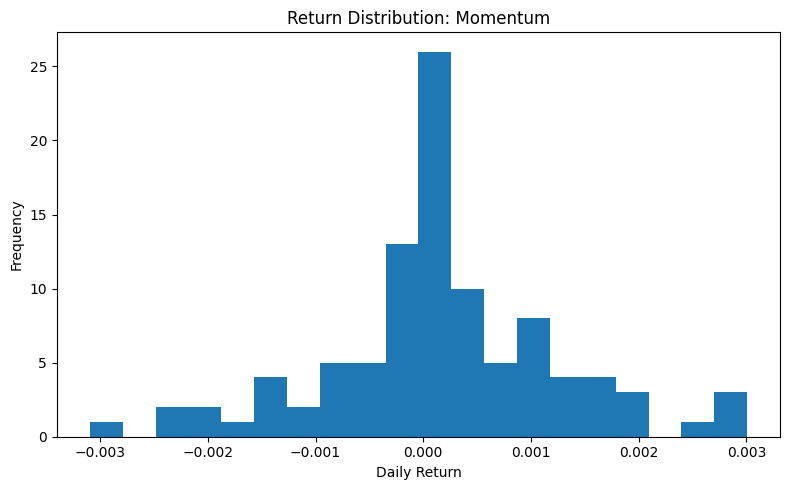

In [11]:
plot_return_distribution(results, "Momentum", figure_dir / "return_distribution.png")

## Key Observations

In this simulation, the buy-and-hold benchmark produced the highest final portfolio value, ending at about $\$$113,000 from a $\$$100,000 initial portfolio. The active rule-based strategies, including momentum, moving average, mean reversion, and random trading, ended closer to the initial portfolio value.

This result suggests that, for this simulated sample path, simply holding the diversified basket performed better than frequent rule-based trading. However, final portfolio value alone is not enough to evaluate a strategy. A strategy can produce a higher ending value while also experiencing larger drawdowns, higher volatility, or worse downside tail risk.

The risk metrics help compare strategies more fairly. Sharpe ratio measures return per unit of volatility, maximum drawdown captures peak-to-trough losses, and VaR/CVaR summarize downside tail risk. These metrics make the backtest more useful than a simple ranking by final portfolio value.

Because the stock price data in this project is simulated sample data, the results should be interpreted as a backtesting demonstration rather than investment advice.